In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter

plt.rcParams["figure.figsize"] = (12,6)

In [2]:
df = pd.read_csv(
    "data/processed/fmcg_sales_clean.csv",
    parse_dates=["date"]
)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
print(df.shape)

df.head()

(1100000, 33)


,date,year,month,day,weekofyear,weekday,is_weekend,is_holiday,temperature,rain_mm,...,discount_pct,promo_flag,gross_sales,net_sales,stock_on_hand,stock_out_flag,lead_time_days,supplier_id,purchase_cost,margin_pct
0,2023-07-21,2023,7,21,29,4,0,0,11.58,0.13,...,0.3,1,73.43,51.40,276,0,10,S041,7.51,-0.016
1,2023-07-22,2023,7,22,29,5,1,0,12.11,1.78,...,0.0,0,104.90,104.90,331,0,9,S011,7.36,0.298
2,2023-07-23,2023,7,23,29,6,1,0,15.62,1.35,...,0.0,0,73.43,73.43,219,0,3,S031,5.42,0.483
3,2023-07-24,2023,7,24,30,0,0,0,17.73,1.07,...,0.0,0,73.43,73.43,346,0,6,S047,7.31,0.303
4,2023-07-25,2023,7,25,30,1,0,0,14.24,9.28,...,0.0,0,41.96,41.96,293,0,6,S030,5.32,0.493


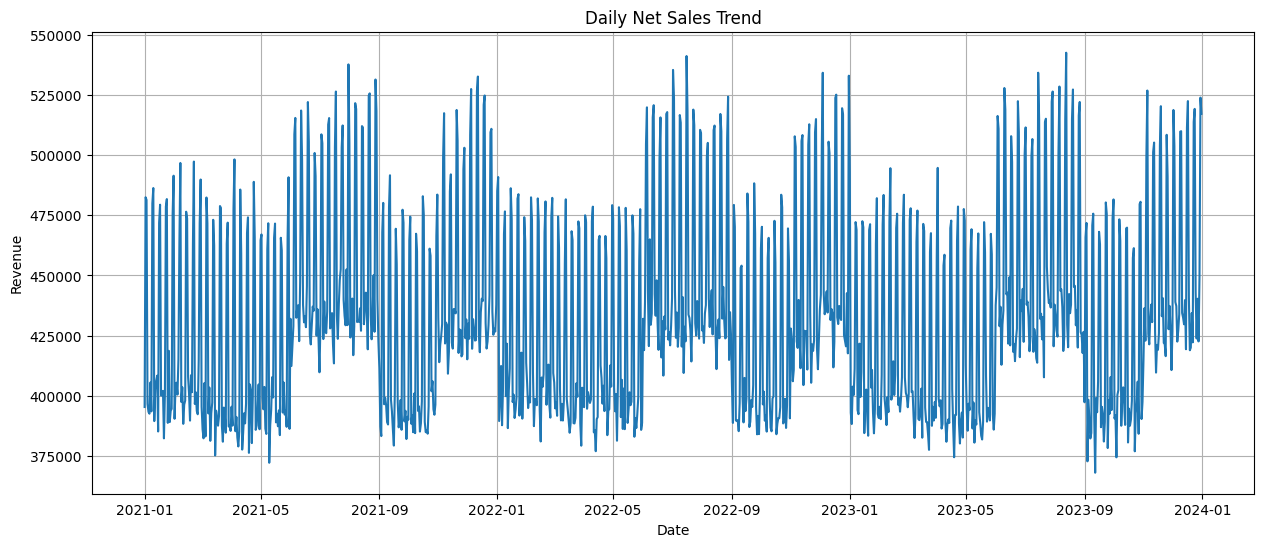

In [4]:
monthly_sales = (
    df.groupby("date")["net_sales"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales["date"],
    monthly_sales["net_sales"]
)

plt.title("Daily Net Sales Trend")

plt.xlabel("Date")

plt.ylabel("Revenue")

plt.grid(True)

plt.show()

Is demand increasing, decreasing, or seasonal?

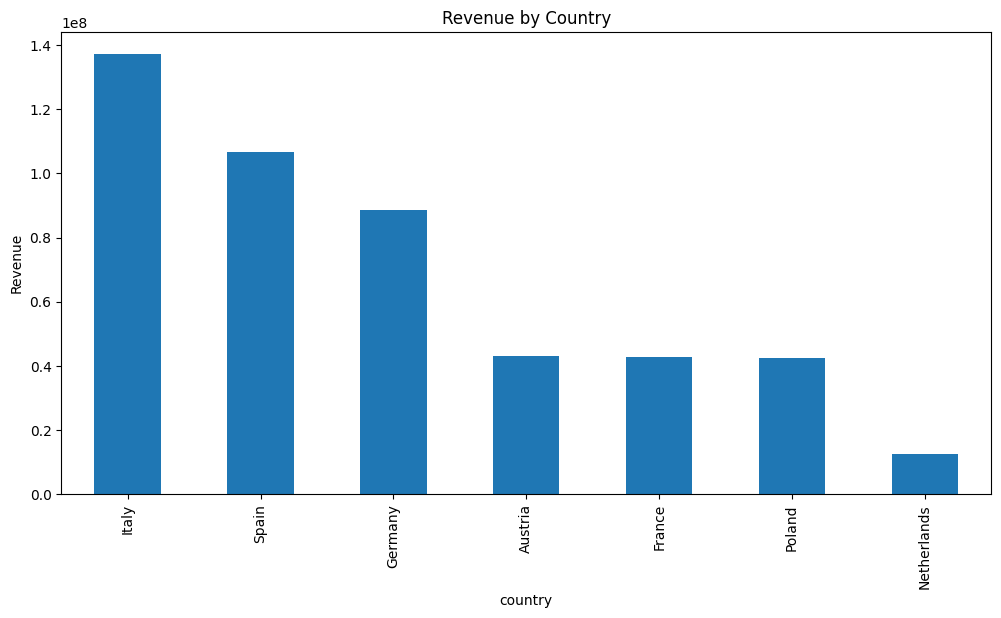

In [5]:
country_sales = (
    df.groupby("country")["net_sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

country_sales.plot(kind="bar")

plt.title("Revenue by Country")

plt.ylabel("Revenue")

plt.show()

Which countries contribute most to revenue?

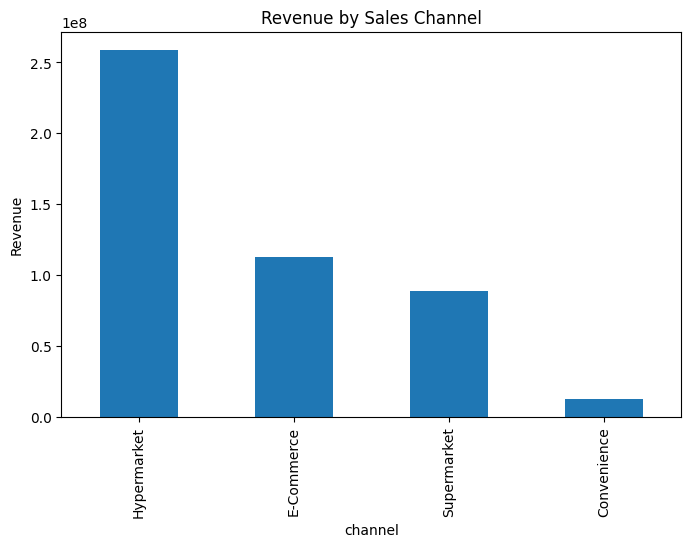

In [6]:
channel_sales = (
    df.groupby("channel")["net_sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

channel_sales.plot(kind="bar")

plt.title("Revenue by Sales Channel")

plt.ylabel("Revenue")

plt.show()

Which fulfillment channel drives the highest sales?

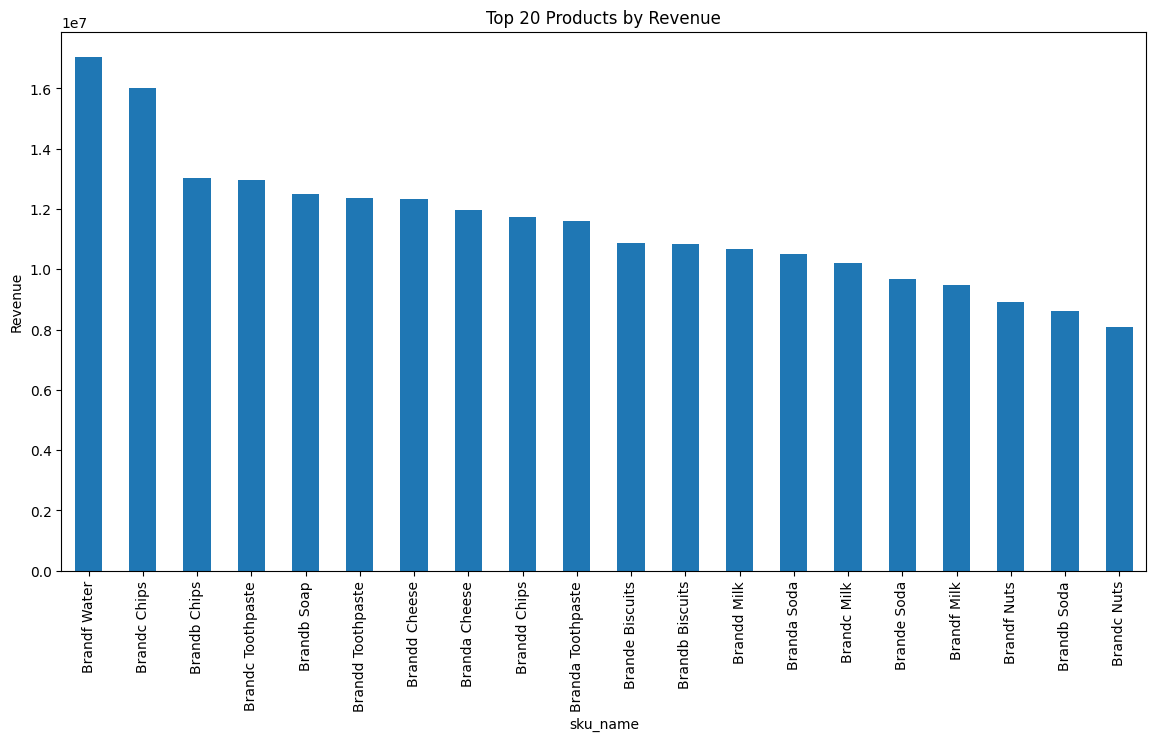

In [7]:
top_products = (
    df.groupby("sku_name")["net_sales"]
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

plt.figure(figsize=(14,7))

top_products.plot(kind="bar")

plt.title("Top 20 Products by Revenue")

plt.ylabel("Revenue")

plt.show()

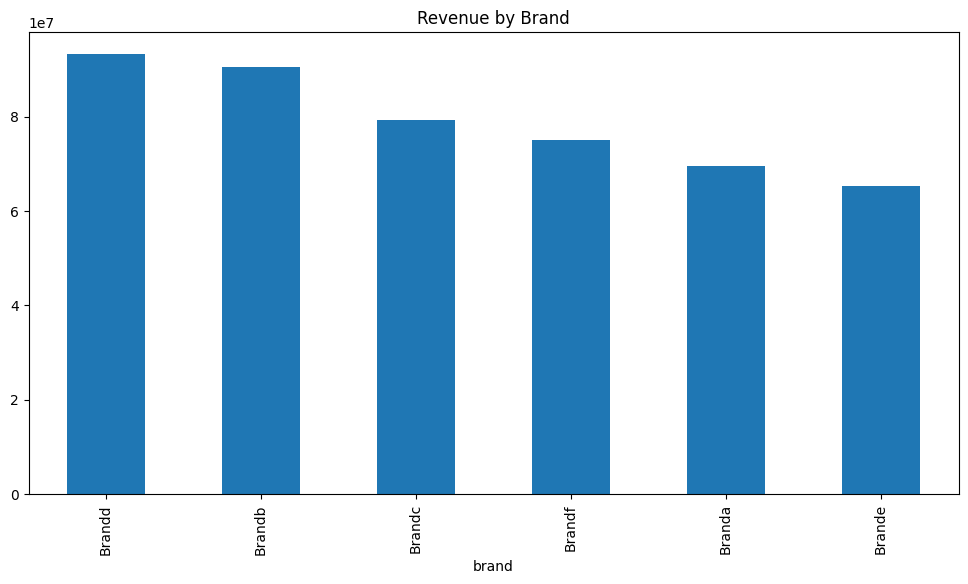

In [8]:
brand_sales = (
    df.groupby("brand")["net_sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

brand_sales.plot(kind="bar")

plt.title("Revenue by Brand")

plt.show()

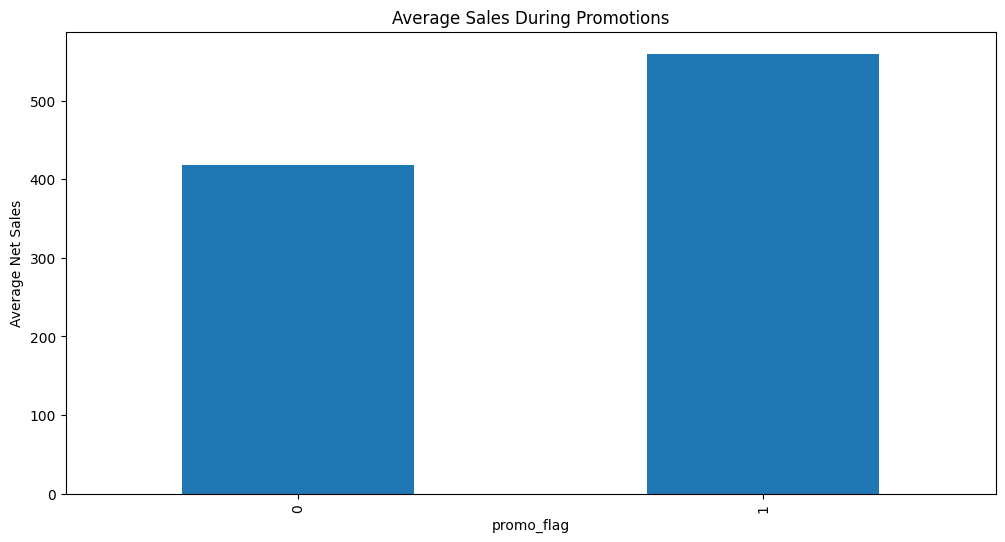

In [9]:
promo = (
    df.groupby("promo_flag")["net_sales"]
      .mean()
)

promo.plot(kind="bar")

plt.title("Average Sales During Promotions")

plt.ylabel("Average Net Sales")

plt.show()

Do promotions actually increase sales?

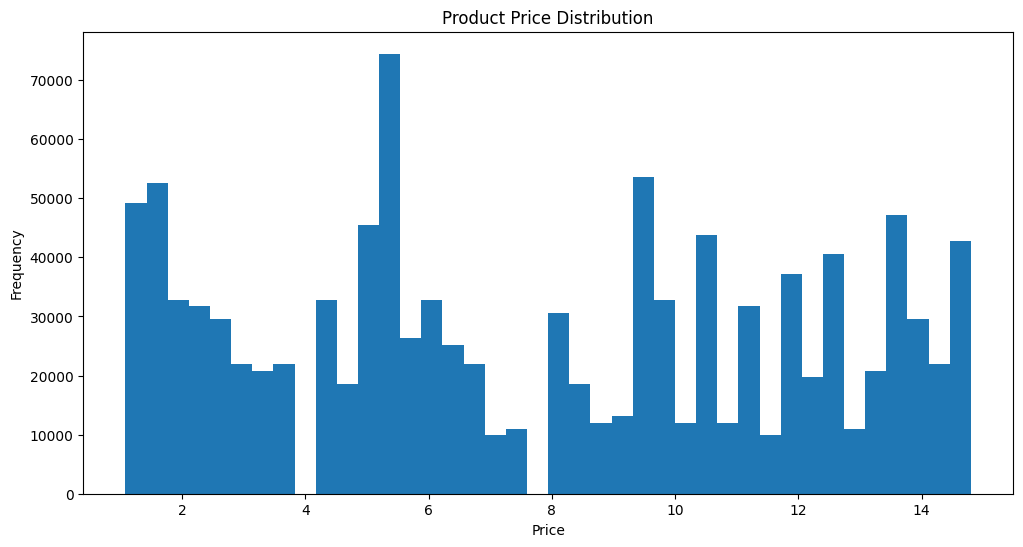

In [10]:
plt.hist(
    df["list_price"],
    bins=40
)

plt.title("Product Price Distribution")

plt.xlabel("Price")

plt.ylabel("Frequency")

plt.show()

Are prices concentrated or widely distributed?

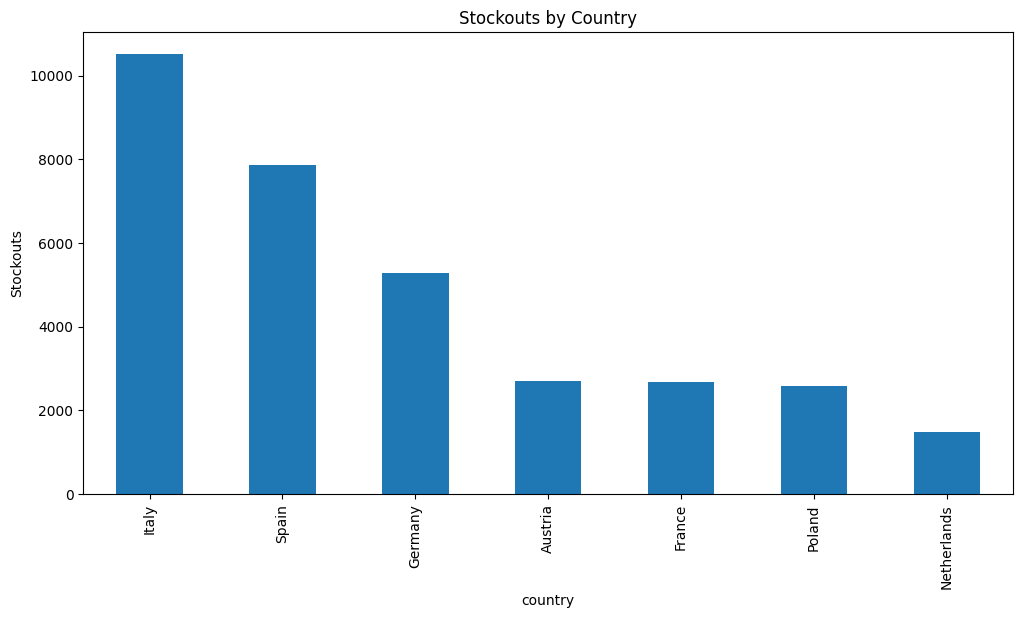

In [11]:
stockouts = (
    df.groupby("country")["stock_out_flag"]
      .sum()
      .sort_values(ascending=False)
)

stockouts.plot(kind="bar")

plt.title("Stockouts by Country")

plt.ylabel("Stockouts")

plt.show()

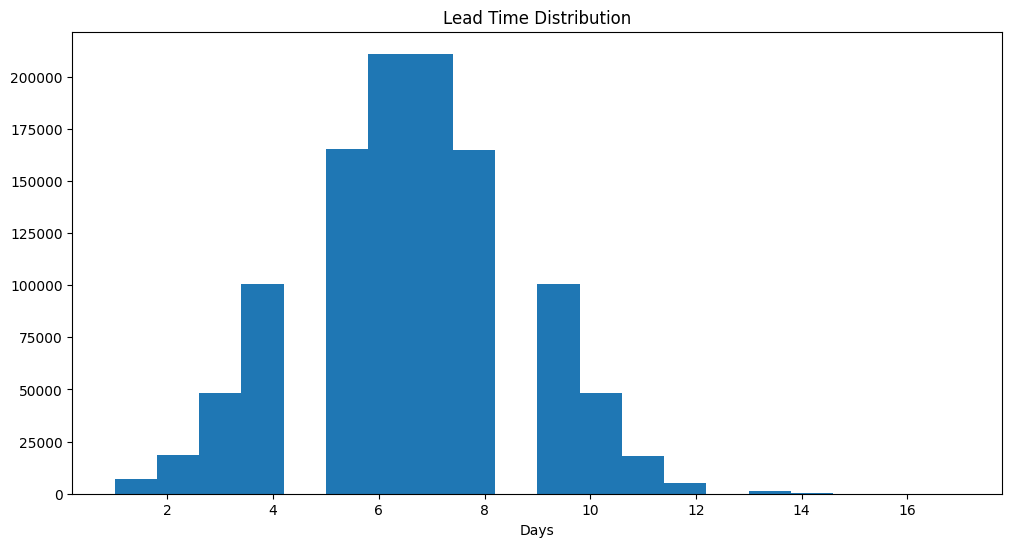

In [12]:
plt.hist(
    df["lead_time_days"],
    bins=20
)

plt.title("Lead Time Distribution")

plt.xlabel("Days")

plt.show()

Are long lead times common?

In [13]:
corr = df[
[
"net_sales",
"gross_sales",
"units_sold",
"list_price",
"discount_pct",
"stock_on_hand",
"lead_time_days"
]
].corr()

corr

,net_sales,gross_sales,units_sold,list_price,discount_pct,stock_on_hand,lead_time_days
net_sales,1.000000,0.992389,0.628485,0.580923,0.082938,0.000511,-0.000193
gross_sales,0.992389,1.000000,0.651696,0.563315,0.170883,0.000426,-0.000139
units_sold,0.628485,0.651696,1.000000,-0.082791,0.292777,-0.000955,0.000949
list_price,0.580923,0.563315,-0.082791,1.000000,-0.042847,0.001177,-0.000648
discount_pct,0.082938,0.170883,0.292777,-0.042847,1.000000,-0.001103,0.000191
stock_on_hand,0.000511,0.000426,-0.000955,0.001177,-0.001103,1.000000,-0.000521
lead_time_days,-0.000193,-0.000139,0.000949,-0.000648,0.000191,-0.000521,1.000000


In [14]:
abc = (
    df.groupby("sku_name")["net_sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

abc.columns = ["SKU","Revenue"]

abc["Revenue %"] = (
    abc["Revenue"] /
    abc["Revenue"].sum()
)

abc["Cumulative %"] = (
    abc["Revenue %"]
    .cumsum()
)

In [15]:
def abc_class(x):

    if x <= 0.80:
        return "A"

    elif x <= 0.95:
        return "B"

    else:
        return "C"

abc["ABC"] = (
    abc["Cumulative %"]
    .apply(abc_class)
)

abc.head(20)

,SKU,Revenue,Revenue %,Cumulative %,ABC
0,Brandf Water,17032424.64,0.036013,0.036013,A
1,Brandc Chips,16000295.02,0.033831,0.069845,A
2,Brandb Chips,13025419.73,0.027541,0.097386,A
3,Brandc Toothpaste,12968809.43,0.027421,0.124807,A
4,Brandb Soap,12496995.90,0.026424,0.151231,A
5,Brandd Toothpaste,12351150.68,0.026115,0.177346,A
6,Brandd Cheese,12326994.00,0.026064,0.203410,A
7,Branda Cheese,11967260.40,0.025304,0.228714,A
8,Brandd Chips,11749108.59,0.024842,0.253556,A
9,Branda Toothpaste,11594508.71,0.024515,0.278072,A


Which product categories generate the highest revenue?

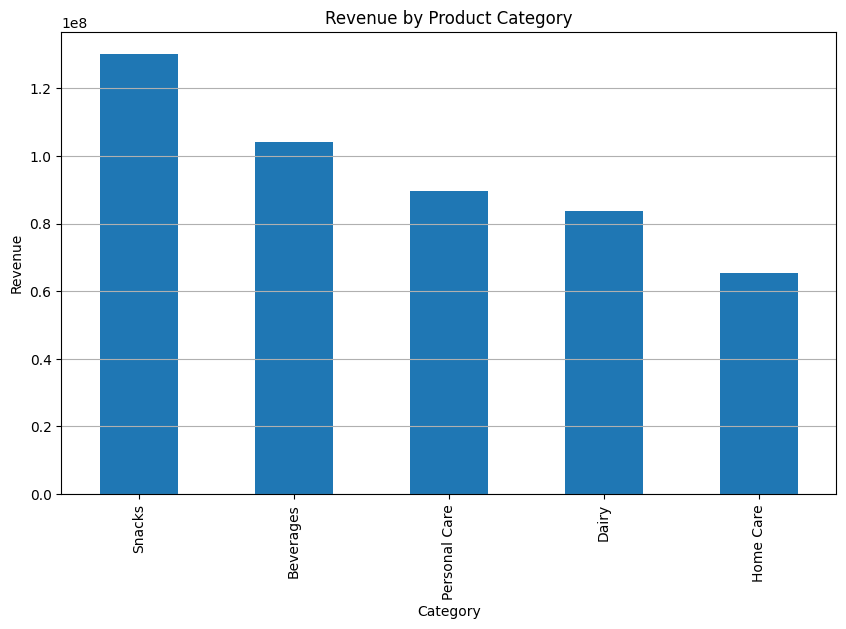

In [16]:
category_sales = (
    df.groupby("category")["net_sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

category_sales.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.grid(axis="y")

plt.show()

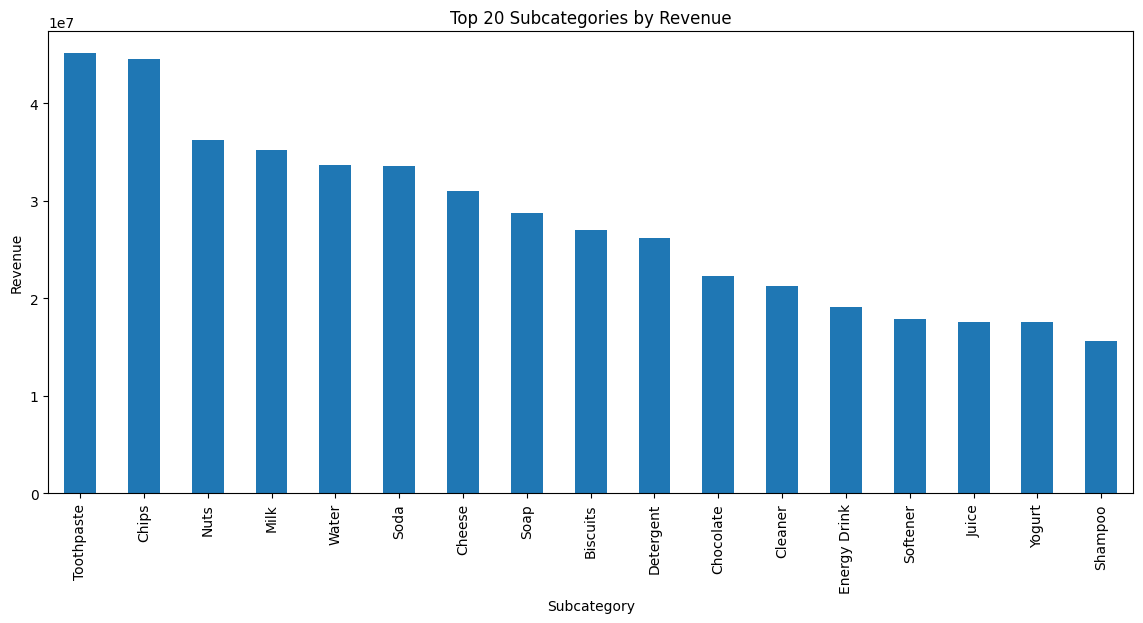

In [17]:
subcategory_sales = (
    df.groupby("subcategory")["net_sales"]
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

plt.figure(figsize=(14,6))

subcategory_sales.plot(kind="bar")

plt.title("Top 20 Subcategories by Revenue")
plt.xlabel("Subcategory")
plt.ylabel("Revenue")

plt.show()

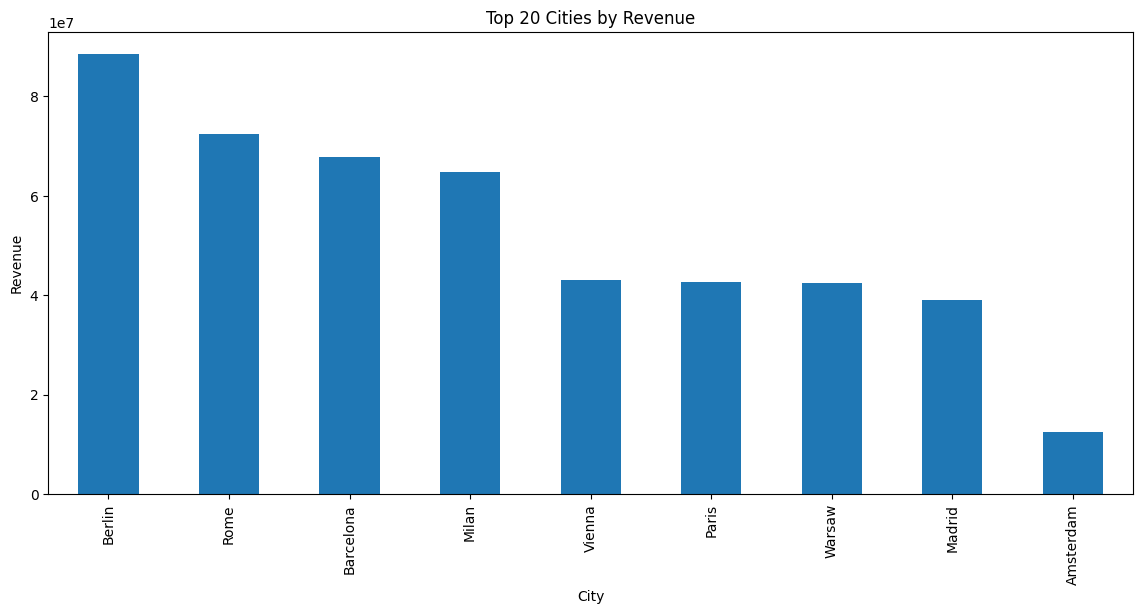

In [18]:
city_sales = (
    df.groupby("city")["net_sales"]
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

plt.figure(figsize=(14,6))

city_sales.plot(kind="bar")

plt.title("Top 20 Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")

plt.show()

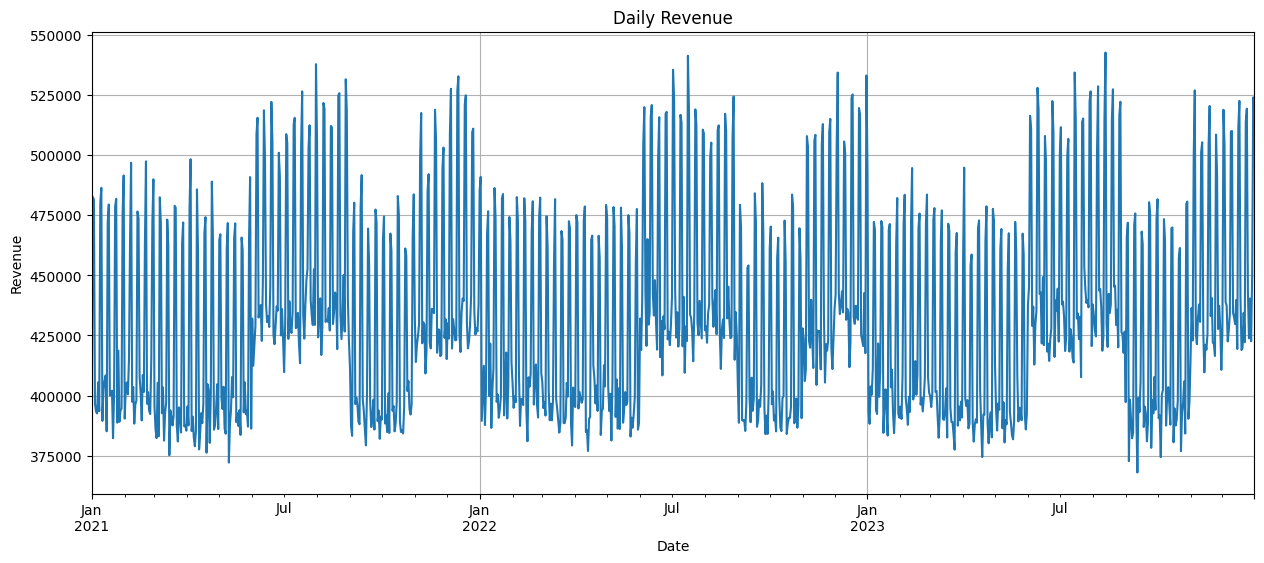

In [19]:
daily_sales = (
    df.groupby("date")["net_sales"]
      .sum()
)

plt.figure(figsize=(15,6))

daily_sales.plot()

plt.title("Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

Is demand stable over time, or are there noticeable peaks and troughs?

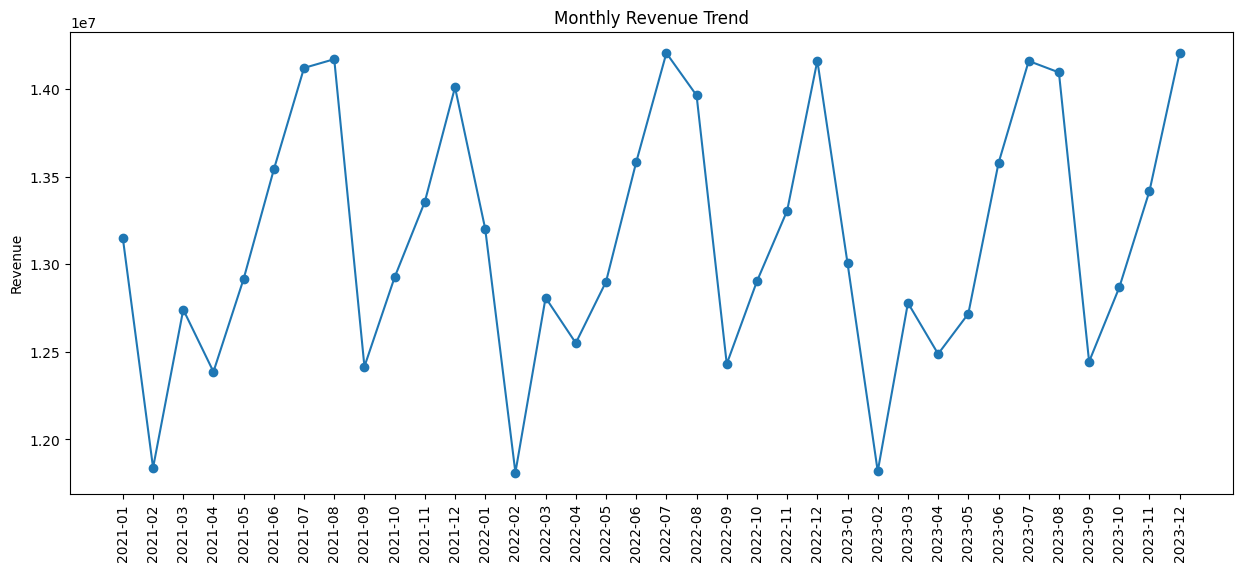

In [20]:
monthly_sales = (
    df.groupby(["year", "month"])["net_sales"]
      .sum()
      .reset_index()
)

monthly_sales["period"] = (
    monthly_sales["year"].astype(str)
    + "-"
    + monthly_sales["month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales["period"],
    monthly_sales["net_sales"],
    marker="o"
)

plt.xticks(rotation=90)

plt.title("Monthly Revenue Trend")

plt.ylabel("Revenue")

plt.show()

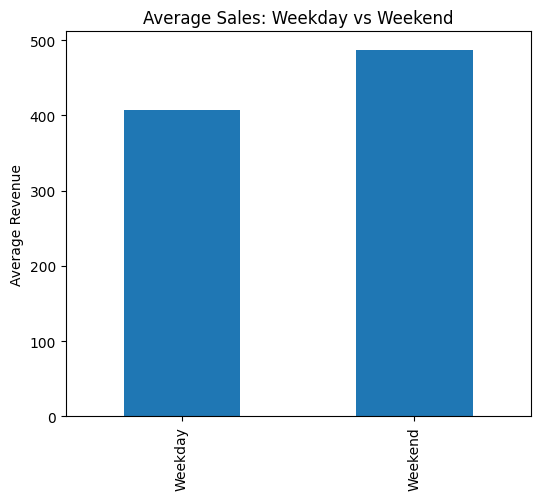

In [21]:
weekend_sales = (
    df.groupby("is_weekend")["net_sales"]
      .mean()
)

weekend_sales.index = ["Weekday", "Weekend"]

plt.figure(figsize=(6,5))

weekend_sales.plot(kind="bar")

plt.title("Average Sales: Weekday vs Weekend")

plt.ylabel("Average Revenue")

plt.show()

Do weekends generate more revenue than weekdays?

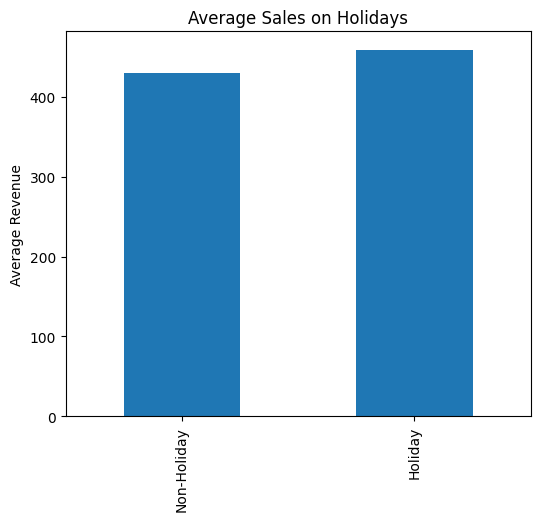

In [22]:
holiday_sales = (
    df.groupby("is_holiday")["net_sales"]
      .mean()
)

holiday_sales.index = ["Non-Holiday", "Holiday"]

plt.figure(figsize=(6,5))

holiday_sales.plot(kind="bar")

plt.title("Average Sales on Holidays")

plt.ylabel("Average Revenue")

plt.show()

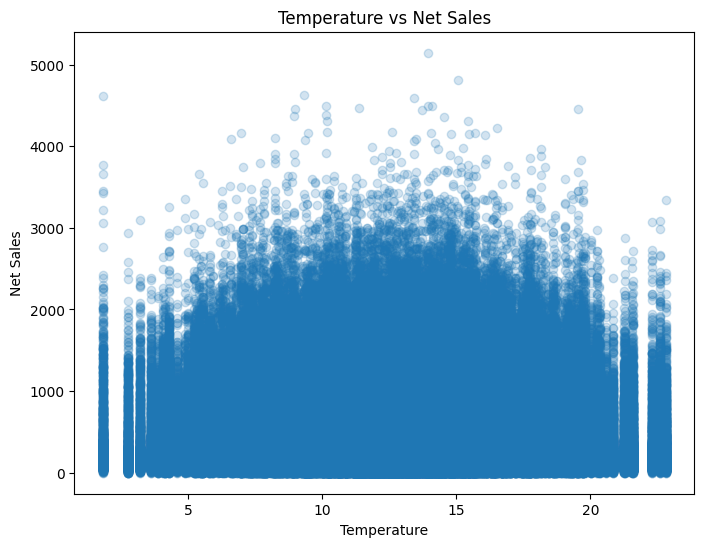

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["temperature"],
    df["net_sales"],
    alpha=0.2
)

plt.title("Temperature vs Net Sales")

plt.xlabel("Temperature")

plt.ylabel("Net Sales")

plt.show()

oes weather appear to influence demand?

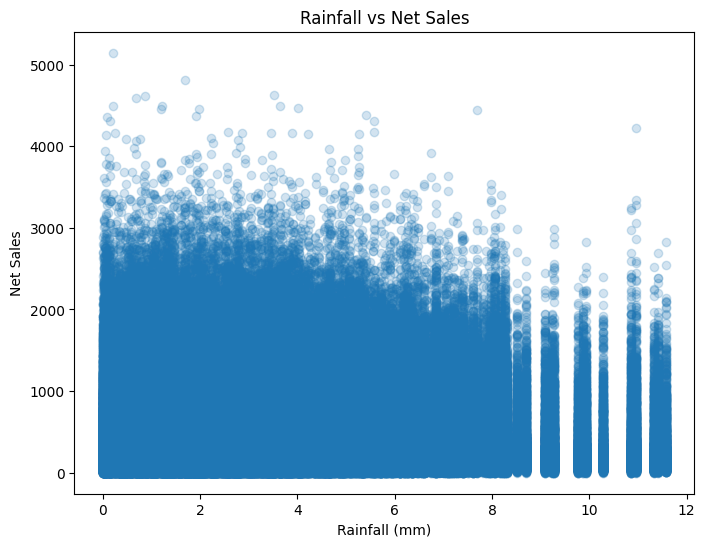

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["rain_mm"],
    df["net_sales"],
    alpha=0.2
)

plt.title("Rainfall vs Net Sales")

plt.xlabel("Rainfall (mm)")

plt.ylabel("Net Sales")

plt.show()

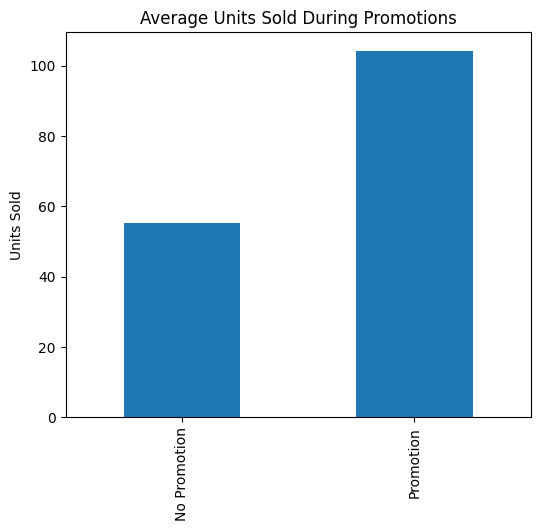

In [25]:
promotion_units = (
    df.groupby("promo_flag")["units_sold"]
      .mean()
)

promotion_units.index = ["No Promotion", "Promotion"]

plt.figure(figsize=(6,5))

promotion_units.plot(kind="bar")

plt.title("Average Units Sold During Promotions")

plt.ylabel("Units Sold")

plt.show()

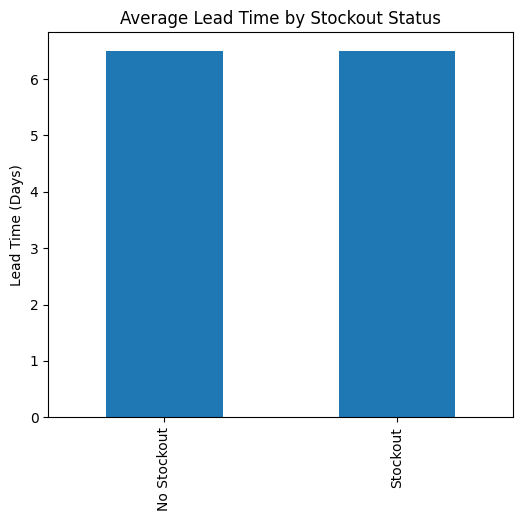

In [26]:
leadtime_stockout = (
    df.groupby("stock_out_flag")["lead_time_days"]
      .mean()
)

leadtime_stockout.index = ["No Stockout", "Stockout"]

plt.figure(figsize=(6,5))

leadtime_stockout.plot(kind="bar")

plt.title("Average Lead Time by Stockout Status")

plt.ylabel("Lead Time (Days)")

plt.show()

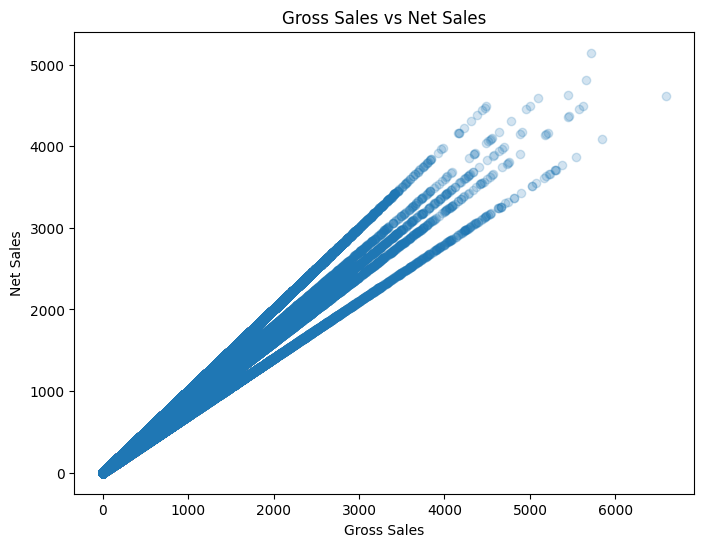

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["gross_sales"],
    df["net_sales"],
    alpha=0.2
)

plt.title("Gross Sales vs Net Sales")

plt.xlabel("Gross Sales")

plt.ylabel("Net Sales")

plt.show()

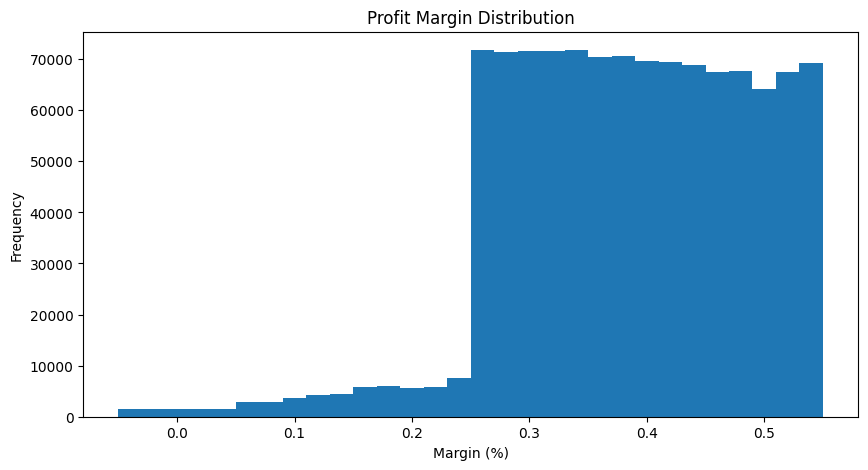

In [28]:
plt.figure(figsize=(10,5))

plt.hist(
    df["margin_pct"],
    bins=30
)

plt.title("Profit Margin Distribution")

plt.xlabel("Margin (%)")

plt.ylabel("Frequency")

plt.show()

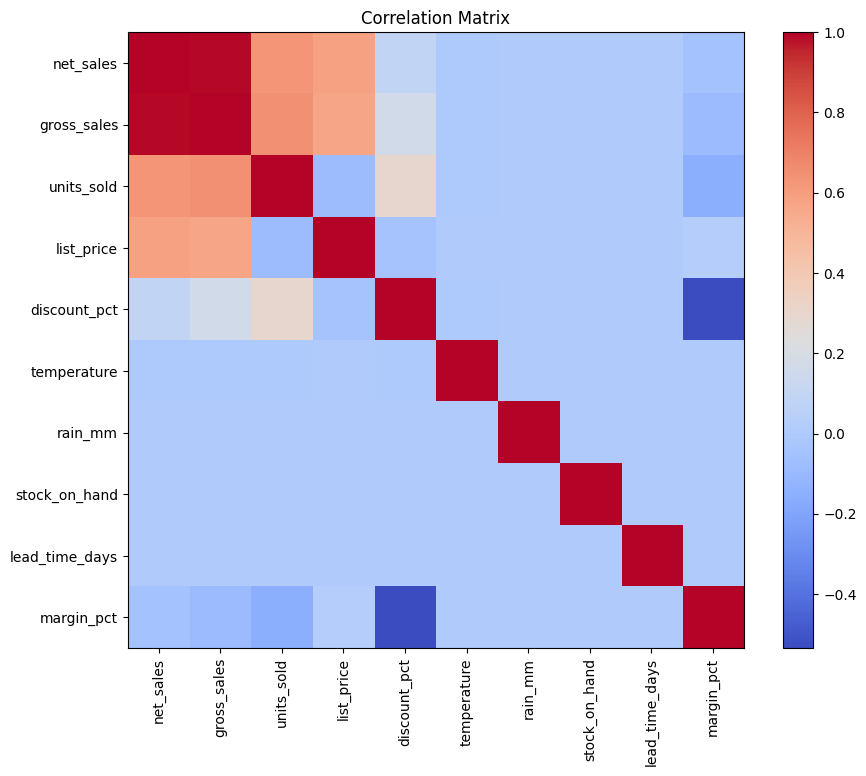

In [29]:
numeric_cols = [
    "net_sales",
    "gross_sales",
    "units_sold",
    "list_price",
    "discount_pct",
    "temperature",
    "rain_mm",
    "stock_on_hand",
    "lead_time_days",
    "margin_pct"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,8))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")

plt.show()

In [30]:
summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Average Daily Revenue",
        "Countries",
        "Cities",
        "Brands",
        "SKUs",
        "Stores"
    ],
    "Value": [
        df["net_sales"].sum(),
        daily_sales.mean(),
        df["country"].nunique(),
        df["city"].nunique(),
        df["brand"].nunique(),
        df["sku_id"].nunique(),
        df["store_id"].nunique()
    ]
})

summary

,Metric,Value
0,Total Revenue,4.729465e+08
1,Average Daily Revenue,4.319146e+05
2,Countries,7.000000e+00
3,Cities,9.000000e+00
4,Brands,6.000000e+00
5,SKUs,1.020000e+02
6,Stores,1.300000e+01


## Key Business Insights

### Revenue Performance
- The highest-performing countries contribute the majority of total revenue.
- A small number of SKUs account for a significant proportion of sales, consistent with the Pareto principle.

### Customer Demand
- Demand shows clear seasonal patterns with recurring peaks and troughs.
- Weekend and holiday sales differ from regular trading days, suggesting calendar effects should be included in forecasting models.

### Promotions
- Promotional campaigns are associated with higher average units sold.
- Discounts increase sales volume but should be balanced against their impact on net revenue and profit margins.

### Inventory and Operations
- Products experiencing stockouts tend to have longer supplier lead times.
- Improving replenishment planning for high-demand items could reduce lost sales.

### Feature Engineering Implications
The analysis suggests that variables such as promotions, holidays, lead time, weather, weekends, and lagged sales are likely to improve forecasting performance and will be incorporated into the machine learning pipeline.